In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


In [6]:
# wine = pd.read_csv('../ml02/wine.csv')
# data   = wine[['alcohol', 'sugar', 'pH']].to_numpy()
# target = wine['class'].to_numpy()           # 0=red, 1=white

wine = pd.read_csv('../ml02/wine.csv')
data   = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()


In [7]:
#데이터 나누기


train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)

#표준화 스케일링
ss = StandardScaler()
train_scaled = ss.fit_transform(train_input)
test_scaled = ss.transform(test_input)

In [8]:
wine.describe()

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


In [10]:
lr = LogisticRegression()
lr.fit(train_scaled,train_target)
print(lr.score(test_scaled, test_target))
lr.score(train_scaled, train_target)

0.7776923076923077


0.7808350971714451

로지스틱회귀의 한계 : 복잡한 비선형적 패턴을 가진 분류 문제 해결 어려움
선으로 긋는 결정 경계로 나누는 것보다, 단계별로 구분선을 쌓아서 가는 방식의 분류가 필요 => 결정 트리

In [13]:
from sklearn.tree import DecisionTreeClassifier
#데이터는 와인 데이터 그대로 사용
dt = DecisionTreeClassifier()
dt.fit(train_input, train_target)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [ ]:
print("훈련 : " , dt.score(train_input,train_target)) # 과적합
print("테스트: ", dt.score(test_input,test_target))

훈련 :  0.996921300750433
테스트:  0.8561538461538462


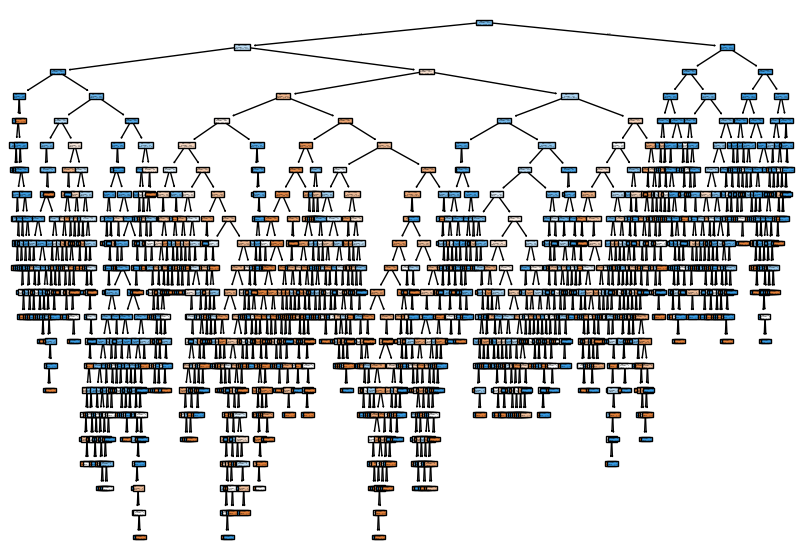

In [16]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# dt는 학습이 완료된 DecisionTreeClassifier 객체 변수명입니다. 
# 만약 변수명이 다르다면 (예: model) 그에 맞게 변경해주세요.

plt.figure(figsize=(10, 7))

# filled=True: 클래스에 따라 노드에 색상을 칠합니다.
# feature_names: 판단 기준이 되는 특성들의 이름을 표시해 줍니다.
plot_tree(dt, 
          filled=True, 
          feature_names=['alcohol', 'sugar', 'pH'])

plt.show()


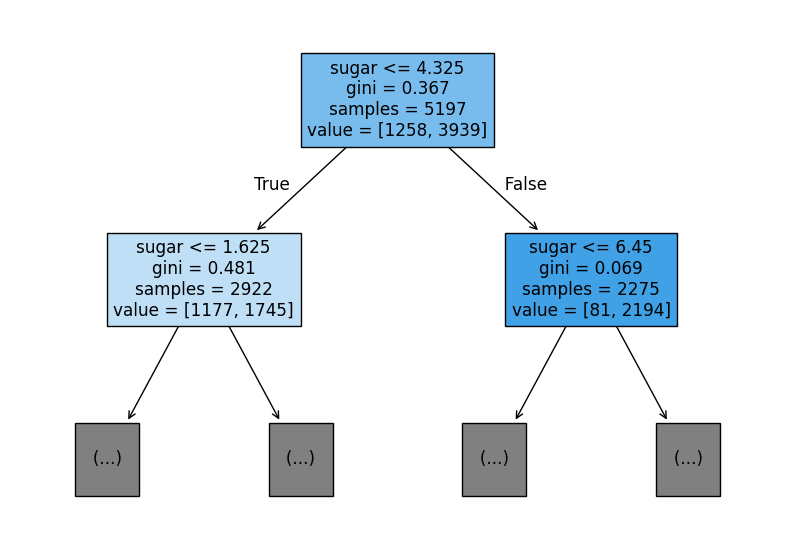

In [17]:
plt.figure(figsize=(10, 7))

# filled=True: 클래스에 따라 노드에 색상을 칠합니다.
# feature_names: 판단 기준이 되는 특성들의 이름을 표시해 줍니다.
plot_tree(dt, 
            max_depth=1,
          filled=True, 
          feature_names=['alcohol', 'sugar', 'pH'])

plt.show()

In [18]:

dt = DecisionTreeClassifier(max_depth=3)
dt.fit(train_input, train_target)
print("훈련 : " , dt.score(train_input,train_target)) # 과적합
print("테스트: ", dt.score(test_input,test_target))

훈련 :  0.8454877814123533
테스트:  0.8415384615384616


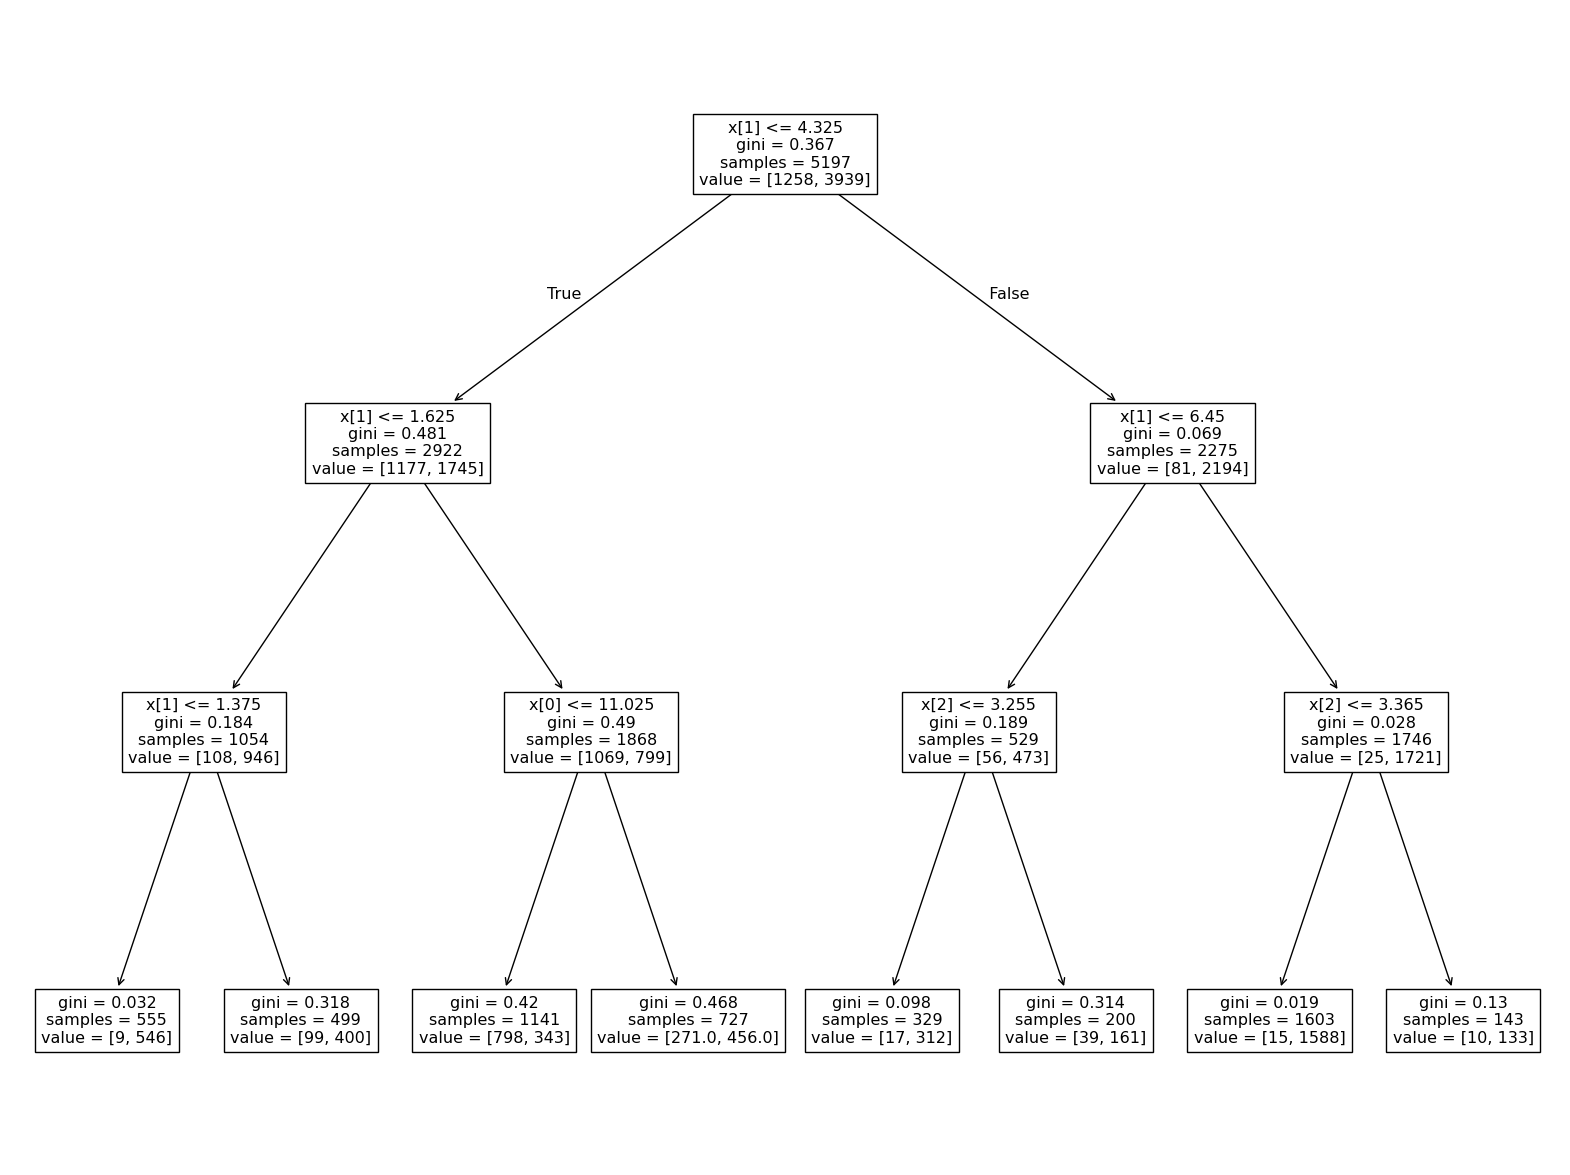

In [19]:
plt.figure(figsize=(20, 15))

# filled=True: 클래스에 따라 노드에 색상을 칠합니다.
# feature_names: 판단 기준이 되는 특성들의 이름을 표시해 줍니다.
plot_tree(dt 
          )

plt.show()


In [ ]:
#특성별 중요도
# [알콜 : 12%, sugar : 87%, ph : 0.8%]
print(dt.feature_importances_)


[0.12345626 0.86862934 0.0079144 ]


In [25]:
for depth in [1,2,3,4,5,None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(train_input, train_target)
    tr = dt.score(train_input, train_target)
    te = dt.score(test_input,test_target)
    print(f"max_depth={depth} : train={tr} test={te}")

max_depth=1 : train=0.7579372715027901 test=0.7376923076923076
max_depth=2 : train=0.8098903213392342 test=0.7961538461538461
max_depth=3 : train=0.8454877814123533 test=0.8415384615384616
max_depth=4 : train=0.8572253223013276 test=0.8484615384615385
max_depth=5 : train=0.8672310948624207 test=0.8607692307692307
max_depth=None : train=0.996921300750433 test=0.8584615384615385


In [28]:
#Random forest algorithm 앙상블, 랜덤포레스트
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

rf = RandomForestClassifier()
rf.fit(train_input, train_target)

scores = cross_validate(rf, train_input, train_target)
scores
print(scores['test_score'])
scores['test_score'].mean()


[0.87980769 0.88173077 0.91241578 0.89316651 0.87969201]


np.float64(0.8893625527504255)

트리 모델에서의 장점 - 설명이 가능함
랜덤 포레스트 - 설명이 힘듬 (점점 블랙박스로 들어가버림 모델이 어떻게 해서 이렇게 나왔는지 설명이 힘듬)

In [ ]:
#XGboost
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
scores = cross_validate(gb, train_input, train_target, return_train_score = True)

In [35]:
print(scores['train_score'].mean())
print(scores['test_score'].mean())

0.8881086892152563
0.8718505219515806


In [ ]:
#히스토 그램 기반 그래디언트 부스팅
from sklearn.ensemble import HistGradientBoostingClassifier
gb= HistGradientBoostingClassifier(random_state=42)

scores

In [ ]:
# XGBoost 모델을 쓰고 싶으실 때 (터미널에 pip install xgboost 설치 필요)
# !uv pip install xgboost
from xgboost import XGBClassifier

gb = XGBClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True)
print(scores['train_score'].mean())
print(scores['test_score'].mean())

Using Python 3.14.5 environment at: C:\Users\금정산2-PC15\Desktop\busan_solution_in_buva\.venv
Resolved 3 packages in 319ms
 Downloaded xgboost
Prepared 1 package in 2.21s
Installed 1 package in 16ms
 + xgboost==3.2.0


0.9567059184812372
0.8783915747390243


In [ ]:
# K-FOLD
# GridSearchCV
